In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Imports Packages/libraries and Data Loading

In [2]:
import pandas as pd
import numpy as np
import string 
import re

from sklearn.feature_extraction.text import(TfidfVectorizer, ENGLISH_STOP_WORDS)
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [4]:
print("train shape", train.shape)
print("test shape", test.shape)

train shape (2000, 8)
test shape (500, 7)


In [5]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [6]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


In [9]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [10]:
#no. of questions
print(len(train))
print(train["answer"].value_counts()) #distribution of answers

2000
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


## Text Cleaning

In [11]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [12]:
sample = train.loc[0, "prompt"]
print("Original: ", sample)

print("\ncleaned format: ",clean_text(sample))

Original:  Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

cleaned format:  pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


In [13]:
clean_train = train.copy()
clean_train["clean_prompt"] = (clean_train["prompt"].apply(clean_text))
clean_train[["prompt", "clean_prompt"]].head()

,prompt,clean_prompt
0,Pick the best possible answer: What is Martin ...,pick the best possible answer what is martin h...
1,What is accelerator-based light-ion fusion?,what is acceleratorbased lightion fusion
2,Determine the correct option: What is the term...,determine the correct option what is the term ...
3,Select the most accurate option: What is Marti...,select the most accurate option what is martin...
4,Identify the correct statement: What is the co...,identify the correct statement what is the con...


In [14]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [15]:
clean_train.head()

,id,prompt,A,B,C,D,E,answer,clean_prompt
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,pick the best possible answer what is martin h...
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,what is acceleratorbased lightion fusion
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,determine the correct option what is the term ...
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,select the most accurate option what is martin...
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,identify the correct statement what is the con...


# Question 

Q1.Calculate the frequency distribution of the correct  answer  (A, B, C, D, E) in train.csv. Based on your counts, what is the sum of the occurrences of the most frequent option and the least frequent option?  

In [16]:
answer_counts = train["answer"].value_counts() #answer counts
print(answer_counts)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64


In [17]:
most_frequent = answer_counts.max()
least_frequent = answer_counts.min()

print("sum of the occurrences of least and most frequent options:", most_frequent+least_frequent)

sum of the occurrences of least and most frequent options: 814


Q2.After converting the prompt column to lowercase and removing all standard punctuation characters (using Python's string.punctuation), split the text by whitespace. What is the total number of unique words (vocabulary size) across the entire cleaned prompt column of train.csv?  
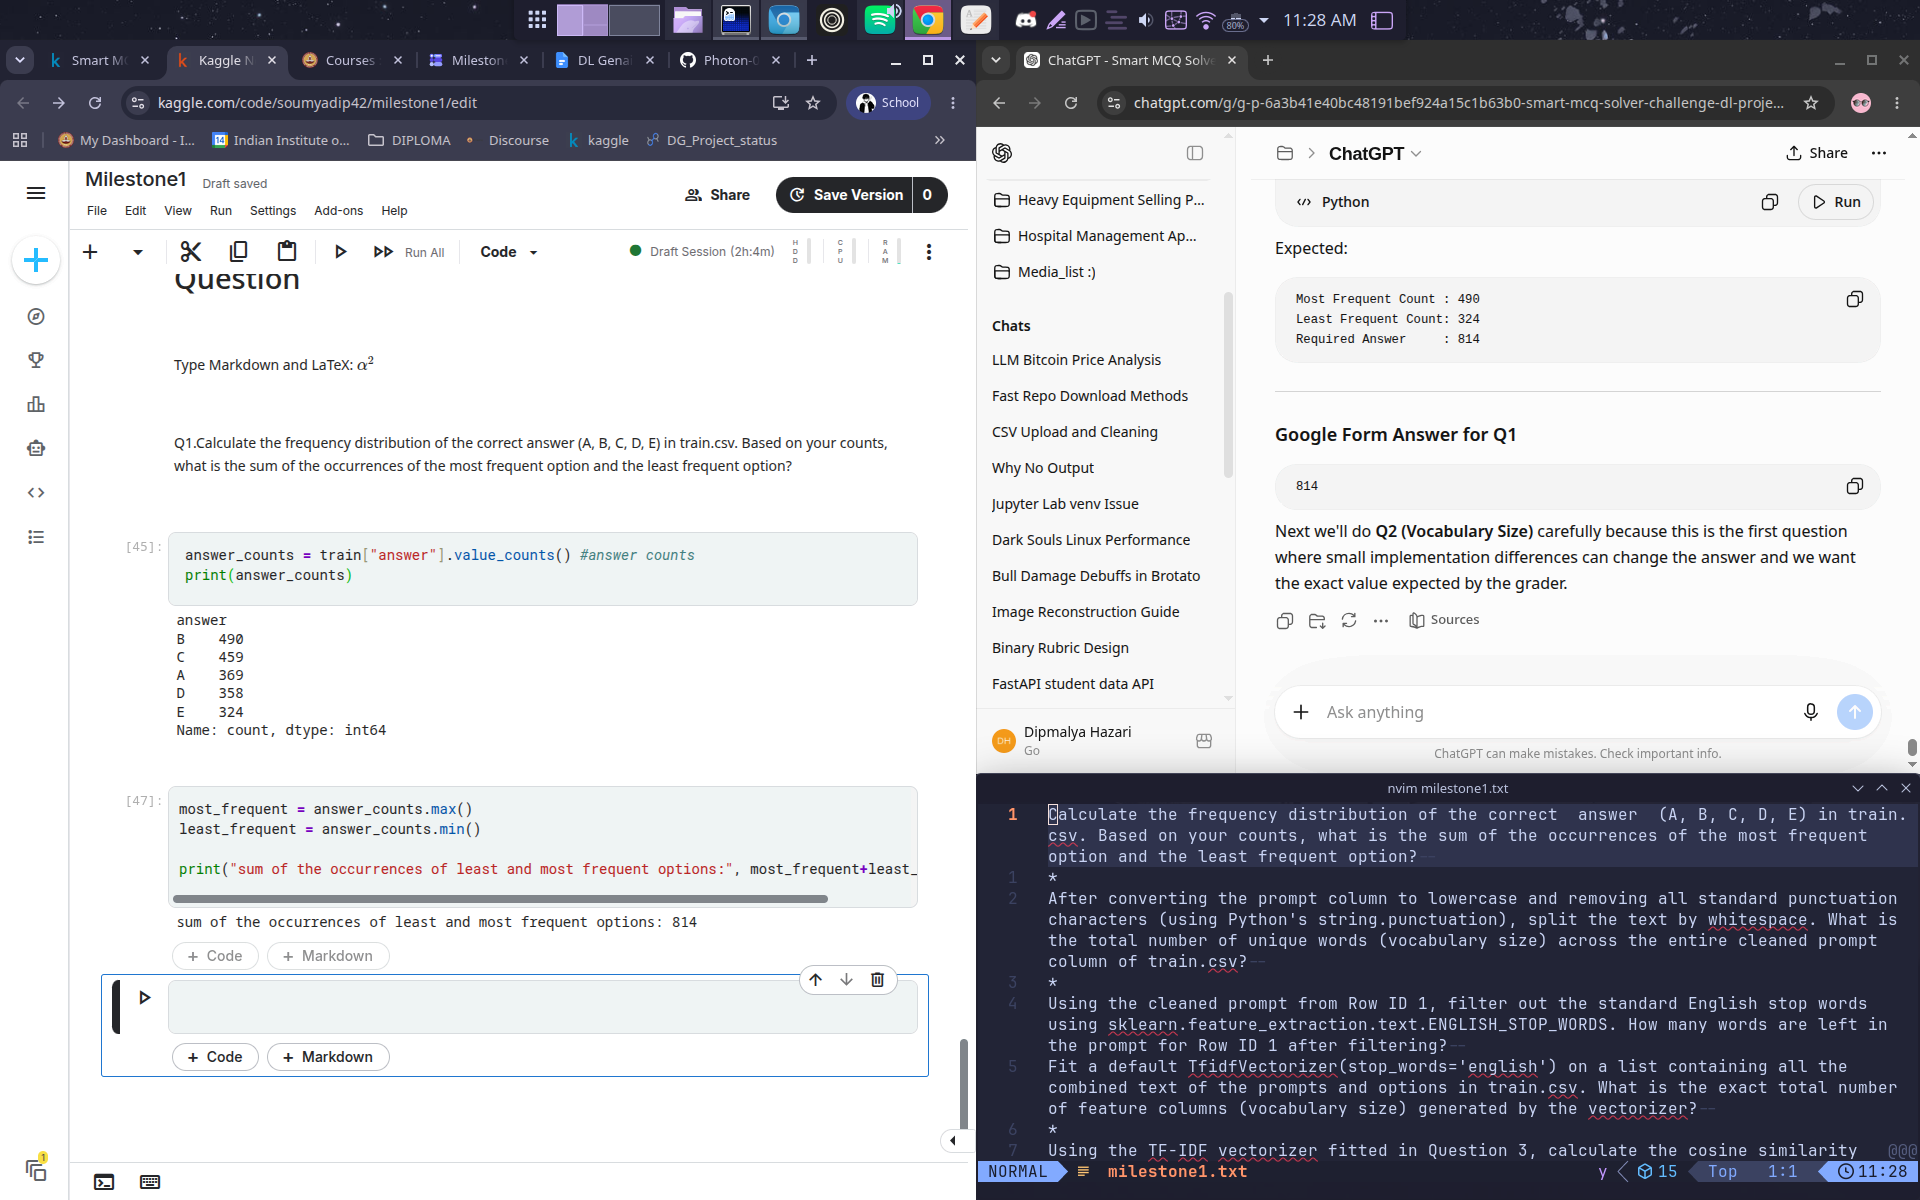

In [18]:
all_words = []
for prompt in clean_train["clean_prompt"]:
    all_words.extend(prompt.split())

distinct_words = set(all_words)
print(len(distinct_words))

859


Q3.Using the cleaned prompt from Row ID 1, filter out the standard English stop words using sklearn.feature_extraction.text.ENGLISH_STOP_WORDS. How many words are left in the prompt for Row ID 1 after filtering?  

In [19]:
row1 = clean_train.loc[clean_train["id"] == 1, "clean_prompt"].iloc[0]
print(row1)

pick the best possible answer what is martin heideggers view on the relationship between time and human existence among the listed options


In [20]:
words = row1.split()
filtered_words = [word for word in words
                 if word not in ENGLISH_STOP_WORDS]
print("count:", len(filtered_words))
print(filtered_words)

count: 13
['pick', 'best', 'possible', 'answer', 'martin', 'heideggers', 'view', 'relationship', 'time', 'human', 'existence', 'listed', 'options']


Q4.Fit a default TfidfVectorizer(stop_words='english') on a list containing all the combined text of the prompts and options in train.csv. What is the exact total number of feature columns (vocabulary size) generated by the vectorizer?  


In [21]:
combined_text = (
    train["prompt"].fillna("") + " " +
    train["A"].fillna("") + " " +
    train["B"].fillna("") + " " +
    train["C"].fillna("") + " " +
    train["D"].fillna("") + " " +
    train["E"].fillna("")
)
vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectorizer.fit_transform(combined_text)

In [22]:
vocab_size = len(vectorizer.get_feature_names_out())
print("Vocabulary Size: ", vocab_size)

Vocabulary Size:  2762


Q5.Using the TF-IDF vectorizer fitted in Question 3, calculate the cosine similarity between the prompt and option A strictly for Row ID 1. What is the resulting similarity score? (Round to 4 decimal places).  

In [23]:
#using the same code to create combined text and fit tf-idf 
q5_row1 = train[train["id"] == 1].iloc[0]
prompt = q5_row1["prompt"]
option_a = q5_row1["A"]
prompt_vect = vectorizer.transform([prompt])
option_a_vect = vectorizer.transform([option_a])

similarity = cosine_similarity(prompt_vect, option_a_vect)[0][0]
print(similarity)

0.27202429519891635


Q6.Expand the logic from Question 4: For every row in train.csv, calculate the cosine similarity between the prompt and each of its 5 options .  Then calculate the percentage of instances where the option with the highest cosine similarity matches the correct answer. 

In [24]:
correct = 0
for _, row in train.iterrows():
    prompt_vect = vectorizer.transform([row["prompt"]])
    similarities = {}
    for option in ["A", "B", "C", "D", "E"]:
        option_vect = vectorizer.transform([row[option]])
        simm = cosine_similarity(prompt_vect, option_vect)[0][0]
        similarities[option] = simm
    predicted = max(similarities, key=similarities.get)
    if predicted == row["answer"]:
        correct += 1
accu_percent = (correct/len(train))*100

print(f"Percentage: {accu_percent: .2f}%")

Percentage:  13.55%


Q7.If the ground truth answer for a question is C, what is the MAP@3 score if a model predicts C A B?

In [25]:
def map_3(actual, predicted):
    """
    actual -- correct answer label
    predicted -- list of top-3 predicted labels
    """
    if actual in predicted:
        rank = predicted.index(actual) + 1
        return 1 / rank

    return 0

In [26]:
print(map_3("C", ["C", "A", "B"]))

1.0


Q8.If the ground truth answer for a question is  B, what is the MAP@3 score if a model predicts D B E?  

In [27]:
print(map_3("B",["D","B","E"]))

0.5


Q9.The Majority Class Baseline: Find the most frequent correct answer in the training set (using your data from Q1). Make a static prediction for every single row where that most frequent answer is your 1st guess, followed by the second most frequent, and then the third most frequent. What is the overall MAP@3 score of this "Majority Class" baseline on train.csv?

In [28]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [29]:
majority_prediction = ["B","C","A"]
scores = []
for actual in train["answer"]:
    score = map_3(actual, majority_prediction)
    scores.append(score)

majority_map3 = sum(scores) / len(scores)
print("Majority baseline MAP@3: ", majority_map3)

Majority baseline MAP@3:  0.42125


Q10.The TF-IDF Pipeline: Build a basic pipeline that evaluates every row in train.csv. For each row, calculate the TF-IDF cosine similarity between the prompt and each of the 5 options. Sort these options from highest similarity to lowest to form your top 3 predictions. What is the final average MAP@3 score of this TF-IDF pipeline across the entire training set? 

In [30]:
scores = []
for _, row in train.iterrows():
    prompt_vect = vectorizer.transform([row["prompt"]])
    similarities = {}
    for option in ["A","B","C","D","E"]:
        option_vect = vectorizer.transform([row[option]])
        similarities[option] = cosine_similarity(prompt_vect,option_vect)[0][0]

    ranked_options = sorted(similarities, key=similarities.get, reverse=True)
    top_predictions = ranked_options[:3]
    score = map_3(row["answer"], top_predictions)
    scores.append(score)

tfidf_map3 = np.mean(scores)
print("TF-IDF Pipeline MAP@3: ", tfidf_map3)

TF-IDF Pipeline MAP@3:  0.2961666666666667
